# PandaX-4T NR yield model vs PRD Fig. 17

Drives the diamx `p4_nest` nuclear-recoil model (`diamx/appletree/plugins/p4_nest.py`) to produce the quantities plotted in Fig. 17 (NR column) of the PandaX-4T signal-response paper (Phys. Rev. D **110**, 023029):

- mean light yield $N_{ph}/\xi$ [photon/keV]
- mean charge yield $N_e/\xi$ [e/keV]
- mean recombination $\langle r\rangle$
- recombination fluctuation $\Delta r$

for the NEST baseline and for P4-NEST (Run0 and Run1).

The model samples quanta with the unified PRD scheme ($N_q=B(\xi/W,L)$, $N_i=B(N_q,1/(1+\alpha))$, $r\sim G(\langle r\rangle,\Delta r)$, $N_e=B(N_i,1-r)$, $N_{ph}=N_q-N_e$) with $L,\alpha,\langle r\rangle_0,\Delta r_0$ from Appendix A Eq. (A2). Because `NRYieldParamsP4NEST` is deterministic and the means propagate exactly through the Eq. (1)/(2) binomials, the mean curves are evaluated analytically from the plugin output plus the Eq. (17) recombination correction; a Monte-Carlo cell cross-checks against the full sampling chain.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import diamx  # registers the p4_nest plugins
import appletree as apt
from diamx.appletree.plugins import p4_nest as P
from diamx.appletree.plugins.p4_nest import _legendre_p3
from diamx.appletree.get_file_path import get_file_path_diamx

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


## Nominal NR parameters
Loaded from `pandax4t_nr_par.json` (NESTv2/PRD nominal + Table II P4-NEST coefficients). `xi_norm` (= 30 keV for NR) is the Eq. 17 correction normalization, stored as a plugin config.

In [2]:
pm = apt.Parameter(get_file_path_diamx('pandax4t_nr_par.json'))
pm.sample_prior()
base = pm.get_all_parameter()
W = base['w']                                   # mean energy per quantum [keV]
XI_NORM = P.NRRecombinationP4NEST('nr').xi_norm_nr.value   # 30 keV (NR)
base, W, XI_NORM

({'w': 0.0137,
  'field': 92.0,
  'liquid_xe_density': 2.8619,
  'p0_nr': 0.7,
  'p1_nr': -1.6,
  'p2_nr': 1.3,
  'p3_nr': -0.6,
  'a_nr': 1.06,
  'd_nr': 0.0},
 0.0137,
 30.0)

## Mean yields from the model
`nr_means` calls the deterministic `NRYieldParamsP4NEST` plugin for $L$, the ion fraction $1/(1+\alpha)$, $\langle r\rangle_0$ and $\Delta r_0$, then applies the Eq. (17) corrections ($\langle r\rangle=\langle r\rangle_0+P_3(\xi/\xi_{norm})e^{-\xi/\xi_{norm}}+d_{nr}$, $\Delta r=\Delta r_0\,A^{NR}$) and propagates the binomial means.

In [3]:
def nr_means(energies, params):
    """Return (light_yield, charge_yield, <r>, dr) vs energy [keV]."""
    energy = jnp.asarray(energies, dtype=float)
    key = jax.random.PRNGKey(0)
    key, lindhard, ion_fraction, recomb_mean0, recomb_std0 = (
        P.NRYieldParamsP4NEST('nr').simulate(key, params, energy)
    )
    e = np.asarray(energy)
    lindhard = np.asarray(lindhard)
    ion_fraction = np.asarray(ion_fraction)
    recomb_mean0 = np.asarray(recomb_mean0)
    recomb_std0 = np.asarray(recomb_std0)

    # Eq. 17 mean-recombination correction (+ per-run shift d_nr)
    u = e / XI_NORM
    correction = _legendre_p3(
        u, params['p0_nr'], params['p1_nr'], params['p2_nr'], params['p3_nr']
    ) * np.exp(-e / XI_NORM)
    r_mean = np.clip(recomb_mean0 + correction + params['d_nr'], 0.0, 1.0)
    dr = recomb_std0 * params['a_nr']

    mean_Nq = (e / W) * lindhard
    mean_Ni = mean_Nq * ion_fraction
    mean_Ne = mean_Ni * (1.0 - r_mean)
    mean_Nph = mean_Nq - mean_Ne
    return mean_Nph / e, mean_Ne / e, r_mean, dr

## Evaluate: NEST baseline vs P4-NEST (Run0, Run1)
- **NEST baseline**: Legendre coefficients = 0, $A^{NR}=1$, $d_{nr}=0$.
- **P4-NEST Run0**: Table II coefficients, $d_{nr}=0$.
- **P4-NEST Run1**: same, $d_{nr}=-0.043$ (Run1 recombination shift). The drift field is held at the Run0 value, since PandaX models the inter-run $\langle r\rangle$ difference via $d_{nr}$ (PRD Sec. VII F).

In [4]:
energies = np.linspace(1.0, 90.0, 300)
nest    = dict(base, p0_nr=0.0, p1_nr=0.0, p2_nr=0.0, p3_nr=0.0, a_nr=1.0, d_nr=0.0)
p4_run0 = dict(base, d_nr=0.0)
p4_run1 = dict(base, d_nr=-0.043)

ly_n, qy_n, r_n, dr_n = nr_means(energies, nest)
ly_0, qy_0, r_0, dr_0 = nr_means(energies, p4_run0)
ly_1, qy_1, r_1, dr_1 = nr_means(energies, p4_run1)

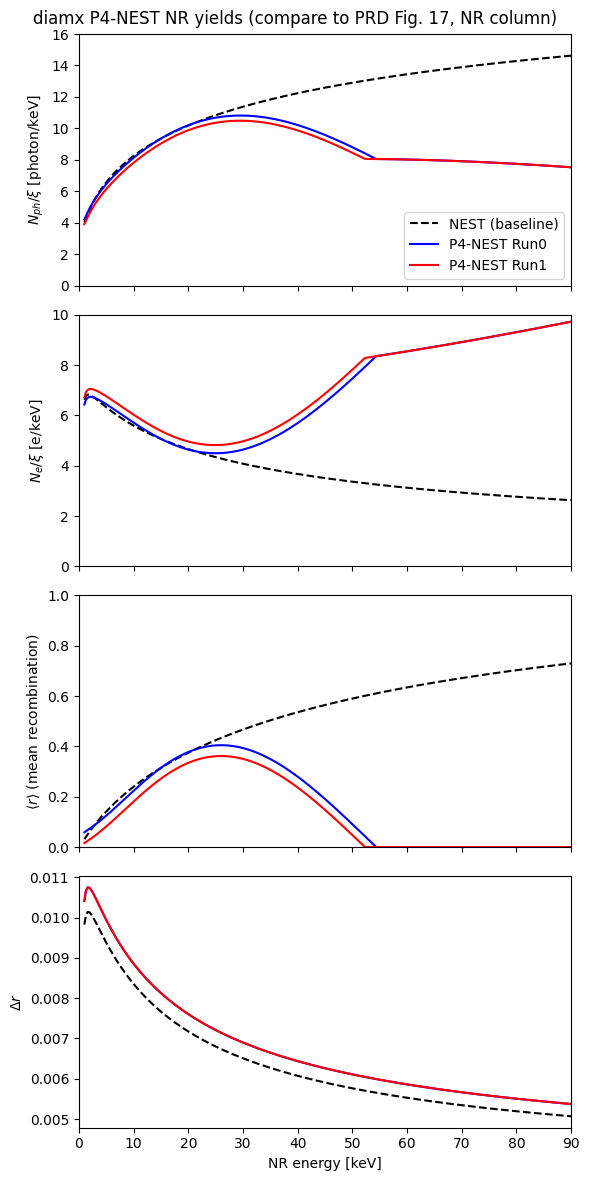

In [5]:
fig, ax = plt.subplots(4, 1, figsize=(6, 12), sharex=True)
for a, (yn, y0, y1) in zip(ax, [(ly_n, ly_0, ly_1), (qy_n, qy_0, qy_1),
                                (r_n, r_0, r_1), (dr_n, dr_0, dr_1)]):
    a.plot(energies, yn, 'k--', label='NEST (baseline)')
    a.plot(energies, y0, 'b-', label='P4-NEST Run0')
    a.plot(energies, y1, 'r-', label='P4-NEST Run1')
ax[0].set_ylabel(r'$N_{ph}/\xi$ [photon/keV]'); ax[0].set_ylim(0, 16); ax[0].legend()
ax[1].set_ylabel(r'$N_e/\xi$ [e/keV]'); ax[1].set_ylim(0, 10)
ax[2].set_ylabel(r'$\langle r \rangle$ (mean recombination)'); ax[2].set_ylim(0, 1)
ax[3].set_ylabel(r'$\Delta r$')  # autoscale; compare scale against Fig. 17
ax[3].set_xlabel('NR energy [keV]'); ax[3].set_xlim(0, 90)
fig.suptitle('diamx P4-NEST NR yields (compare to PRD Fig. 17, NR column)')
fig.tight_layout()
plt.show()

## Monte-Carlo cross-check
Run the full 4-plugin sampling chain at a few energies and confirm the sampled mean yields match the analytic curves above.

In [6]:
def nr_mc(E, params, n=400_000):
    key = jax.random.PRNGKey(1)
    en = jnp.full(n, float(E))
    key, lin, ionf, rm0, rs0 = P.NRYieldParamsP4NEST('nr').simulate(key, params, en)
    key, nq = P.NRTotalQuantaP4NEST('nr').simulate(key, params, en, lin)
    key, ni, nex = P.NRIonizationP4NEST('nr').simulate(key, params, nq, ionf)
    key, nph, ne = P.NRRecombinationP4NEST('nr').simulate(
        key, params, nq, ni, rm0, rs0, en)
    return float(np.mean(np.asarray(nph))) / E, float(np.mean(np.asarray(ne))) / E

print('E[keV]   LY(analytic)  LY(MC)    QY(analytic)  QY(MC)')
for E in [5.0, 20.0, 50.0]:
    ly_mc, qy_mc = nr_mc(E, p4_run0)
    i = int(np.argmin(np.abs(energies - E)))
    print(f'{E:6.1f}   {ly_0[i]:11.3f}  {ly_mc:7.3f}   {qy_0[i]:11.3f}  {qy_mc:7.3f}')

E[keV]   LY(analytic)  LY(MC)    QY(analytic)  QY(MC)
   5.0         6.401    6.458         6.461    6.446
  20.0        10.207   10.204         4.636    4.642
  50.0         8.784    8.805         7.486    7.465


## Comparison with Fig. 17 and a known caveat
At low (WIMP-relevant) NR energy the P4-NEST light/charge yields track the NEST baseline and reproduce Fig. 17: $N_{ph}/\xi\approx8$, $N_e/\xi\approx5.6$ at 10 keV.

**Recombination fluctuation $\Delta r$:** here $\zeta_{NR}=\langle N_e\rangle W/(1000\,\xi)$ is W-based (Eq. A2), giving $\Delta r$ peaking $\approx0.011$ at low energy. Verify this scale against the Fig. 17 NR $\Delta r$ axis: if the figure's $\Delta r$ peaks $\sim0.1$ rather than $\sim0.01$, the amplitude or normalization of $\Delta r_0$ needs revisiting (the quenched electron fraction $\langle N_e\rangle/(\langle N_e\rangle+\langle N_{ph}\rangle)\approx0.5$ would give $\sim0.1$, but that is not the Eq. A2 definition).

**Caveat (correction convention under review):** above ~25-40 keV the Eq. 17 Legendre term — taken here with the literal argument $\xi/\xi_{norm}$ — overshoots and drives $\langle r\rangle\to0$ near ~53 keV, so the high-energy P4-NEST light/charge yields diverge from NEST. In Fig. 17 the P4-NEST and NEST curves nearly overlap across the whole 1-90 keV range, so the exact Legendre argument/normalization PandaX used still needs to be confirmed. This affects only the high-energy NR band, not the low-energy WIMP region.